# 항균 펩타이드(AMP) 후보 서열 분류

서열의 물리화학적 특성을 이용해 AMP와 비AMP를 분류하는 머신러닝 파이프라인.

**데이터**
- 학습: AMPlify 데이터셋 (AMP 3,338 / 비AMP 3,338)
- 예측 대상: APD 데이터베이스 (1,495개)

**흐름**: FASTA 파싱 → 특성 추출 → EDA → 모델 비교 → 후보 예측

## 1. 라이브러리 및 FASTA 파서

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report


def read_fasta(filename, prefix=">"):
    """FASTA 파일을 읽어 {id: sequence} 딕셔너리로 반환."""
    sequences = {}
    with open(filename) as f:
        cur_id, cur_seq = None, ""
        for line in f:
            line = line.strip()
            if line.startswith(prefix) and prefix != ">" or line.startswith(">"):
                if cur_id:
                    sequences[cur_id] = cur_seq
                cur_id, cur_seq = line[1:], ""
            elif cur_id and line:
                cur_seq += line
        if cur_id:
            sequences[cur_id] = cur_seq
    return sequences

## 2. 데이터 로드

AMP=1, 비AMP=0으로 라벨링하여 하나의 DataFrame으로 결합.

In [2]:
amp = read_fasta("AMPlify_AMP_train_common.fa")
non_amp = read_fasta("AMPlify_non_AMP_train_balanced.fa")

data = []
for seq_id, seq in amp.items():
    data.append({"id": seq_id, "sequence": seq, "label": 1})
for seq_id, seq in non_amp.items():
    data.append({"id": seq_id, "sequence": seq, "label": 0})

df = pd.DataFrame(data)
print(f"AMP: {len(amp)}, non-AMP: {len(non_amp)}, 전체: {len(df)}")
df.head()

AMP: 3338, non-AMP: 3338, 전체: 6676


,id,sequence,label
0,trAMP0001,GLLDTFKNLALNAAKSAGVSVLNSLSCKLSKTC,1
1,trAMP0002,AKKPVAKKAAGGVKKPK,1
2,trAMP0003,GIIDIAKKLVGGIRNVLGI,1
3,trAMP0004,MAGFLKVVQLLAKYGSKAVQWAWANKGKILDWLNAGQAIDWVVSKI...,1
4,trAMP0005,YGPGDGHGGGHGGGHGGGHGNGQGGGHGHGPGGGFGGGHGGGHGGG...,1


## 3. 물리화학적 특성 추출

각 서열에서 총 28개 특성을 계산한다.
- 길이, 순전하(net charge), 양전하/음전하 비율
- 소수성, 방향족, 글리신, 프롤린 비율
- 아미노산 20종 조성

In [3]:
def extract_features(seq):
    """서열 하나에서 28개 물리화학적 특성을 계산."""
    seq = seq.upper()
    L = len(seq)
    pos = (seq.count("K") + seq.count("R")) / L
    neg = (seq.count("D") + seq.count("E")) / L

    feat = {
        "length": L,
        "pos_charge": pos,
        "neg_charge": neg,
        "net_charge": pos - neg,
        "hydrophobic": sum(seq.count(a) for a in "AVILMFWP") / L,
        "aromatic": sum(seq.count(a) for a in "FWY") / L,
        "glycine": seq.count("G") / L,
        "proline": seq.count("P") / L,
    }
    # 아미노산 20종 조성
    for aa in "ACDEFGHIKLMNPQRSTVWY":
        feat[aa] = seq.count(aa) / L
    return feat


df = df[df["sequence"].str.len() > 0].reset_index(drop=True)

features = df["sequence"].apply(extract_features)
df_features = pd.DataFrame(list(features))
df_features["label"] = df["label"].values

print(f"특성 수: {df_features.shape[1] - 1}개")
df_features.head()

특성 수: 28개


,length,pos_charge,neg_charge,net_charge,hydrophobic,aromatic,glycine,proline,A,C,...,N,P,Q,R,S,T,V,W,Y,label
0,33,0.121212,0.030303,0.090909,0.424242,0.030303,0.060606,0.000000,0.121212,0.060606,...,0.090909,0.000000,0.000000,0.000000,0.151515,0.060606,0.060606,0.000000,0.000000,1
1,17,0.411765,0.000000,0.411765,0.470588,0.000000,0.117647,0.117647,0.235294,0.000000,...,0.000000,0.117647,0.000000,0.000000,0.000000,0.000000,0.117647,0.000000,0.000000,1
2,19,0.157895,0.052632,0.105263,0.526316,0.000000,0.210526,0.000000,0.052632,0.000000,...,0.052632,0.000000,0.000000,0.052632,0.000000,0.000000,0.105263,0.000000,0.000000,1
3,53,0.150943,0.037736,0.113208,0.547170,0.113208,0.094340,0.000000,0.132075,0.000000,...,0.037736,0.000000,0.075472,0.000000,0.037736,0.000000,0.094340,0.075472,0.018868,1
4,84,0.011905,0.011905,0.000000,0.071429,0.059524,0.630952,0.047619,0.011905,0.000000,...,0.011905,0.047619,0.023810,0.011905,0.023810,0.011905,0.000000,0.000000,0.047619,1


## 4. 탐색적 분석 (EDA)

주요 8개 특성의 AMP vs 비AMP 분포 비교.

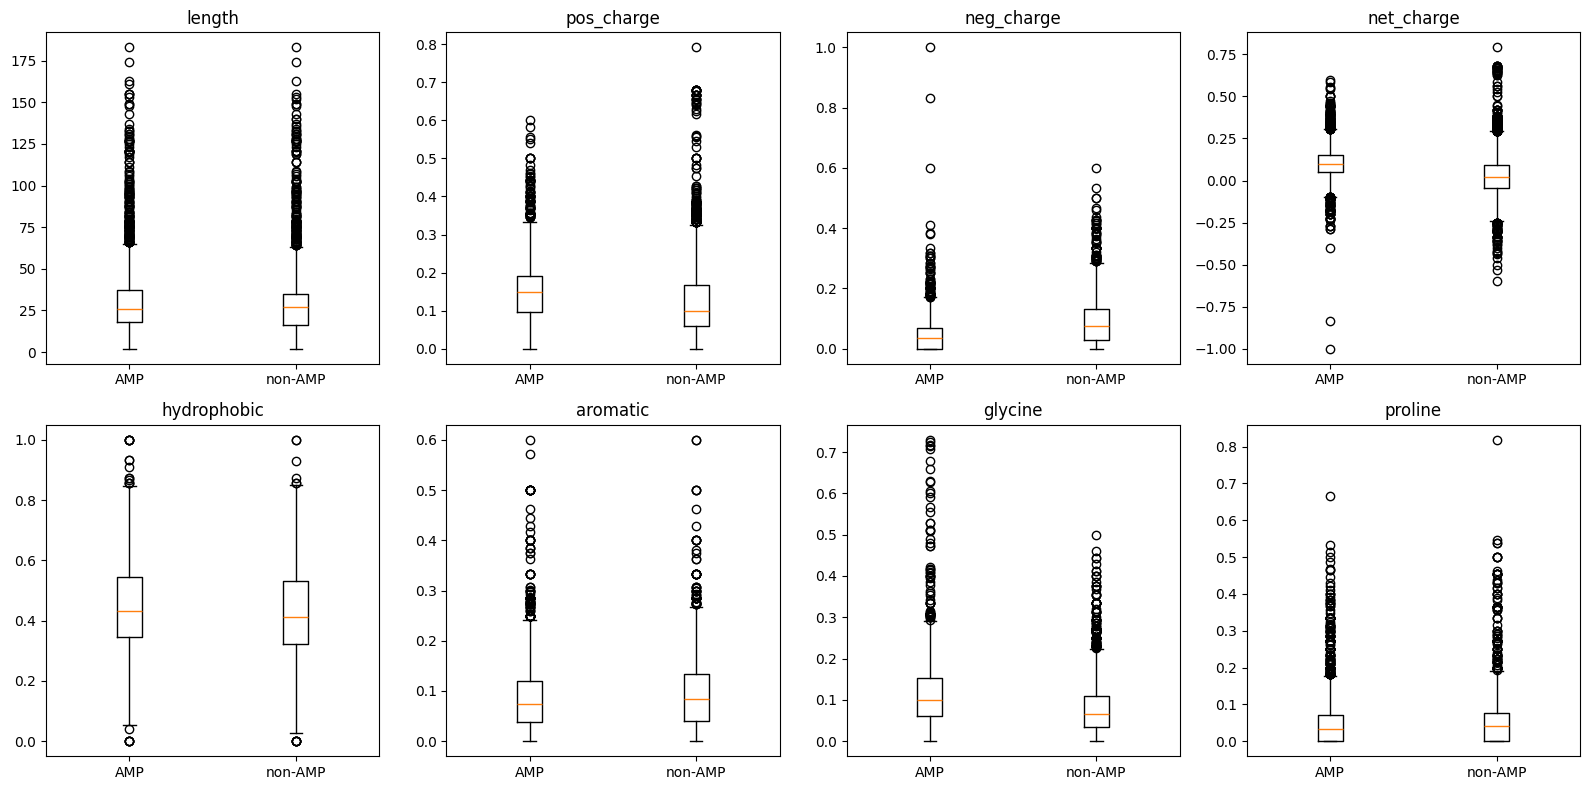

In [4]:
main_feats = ["length", "pos_charge", "neg_charge", "net_charge",
              "hydrophobic", "aromatic", "glycine", "proline"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), main_feats):
    amp_v = df_features[df_features["label"] == 1][feat]
    non_v = df_features[df_features["label"] == 0][feat]
    ax.boxplot([amp_v, non_v], tick_labels=["AMP", "non-AMP"])
    ax.set_title(feat)
plt.tight_layout()
plt.show()

## 5. 주성분분석 (PCA)

28개 특성을 2차원으로 축소하여 두 집단의 분포를 확인.

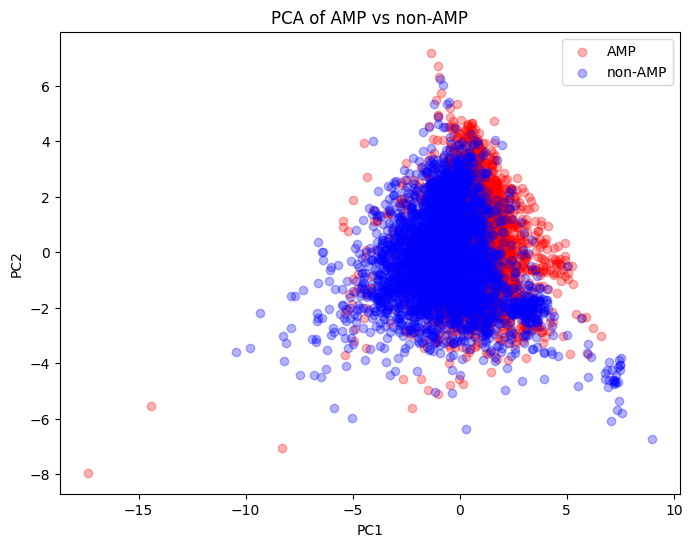

In [5]:
X = df_features.drop("label", axis=1)
y = df_features["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], alpha=0.3, label="AMP", color="red")
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], alpha=0.3, label="non-AMP", color="blue")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of AMP vs non-AMP")
plt.show()

## 6. 모델 학습 및 비교

학습/평가 데이터를 8:2로 분할하고 4종 모델을 비교한다.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True, random_state=42),
}

print("모델별 평가 데이터 정확도")
print("-" * 35)
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"{name:22s}: {acc:.3f}")

모델별 평가 데이터 정확도
-----------------------------------


Random Forest         : 0.894


Gradient Boosting     : 0.870
Logistic Regression   : 0.778


SVM                   : 0.899


## 7. 최종 모델 (SVM) 상세 평가

정확도가 가장 높은 SVM을 최종 모델로 선정.

In [7]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["non-AMP", "AMP"]))

              precision    recall  f1-score   support

     non-AMP       0.89      0.91      0.90       647
         AMP       0.91      0.89      0.90       689

    accuracy                           0.90      1336
   macro avg       0.90      0.90      0.90      1336
weighted avg       0.90      0.90      0.90      1336



## 8. 변수 중요도

SVM은 변수 중요도를 직접 제공하지 않아, Random Forest로 별도 분석.

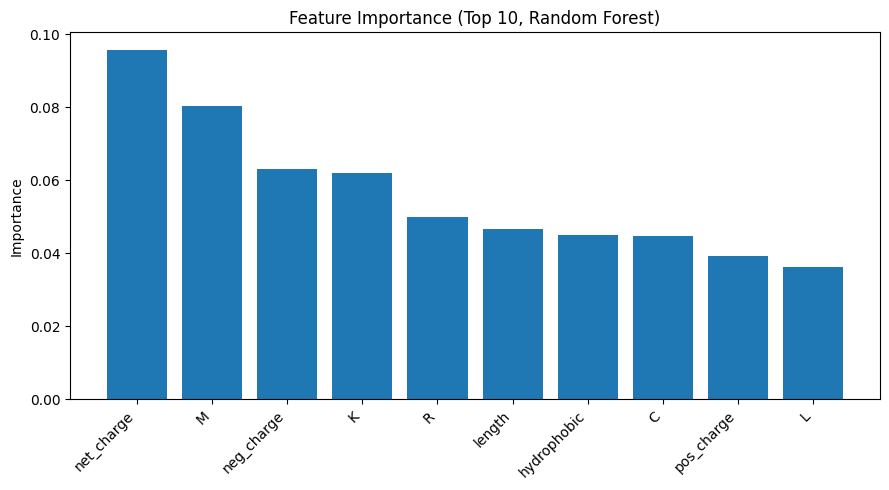

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1][:10]
names = X.columns.tolist()

plt.figure(figsize=(9, 5))
plt.bar(range(len(idx)), importances[idx])
plt.xticks(range(len(idx)), [names[i] for i in idx], rotation=45, ha="right")
plt.title("Feature Importance (Top 10, Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## 9. APD 후보 예측

학습에 사용하지 않은 독립 데이터(APD)로 모델의 일반화 가능성을 확인.

In [9]:
apd = read_fasta("results.fasta", prefix=">AP0")
df_apd = pd.DataFrame({"id": list(apd.keys()), "sequence": list(apd.values())})
df_apd = df_apd[df_apd["sequence"].str.len() > 0].reset_index(drop=True)

apd_feats = df_apd["sequence"].apply(extract_features)
df_apd_features = pd.DataFrame(list(apd_feats))
X_apd = scaler.transform(df_apd_features)

df_apd["amp_probability"] = svm.predict_proba(X_apd)[:, 1]

top = df_apd.sort_values("amp_probability", ascending=False).head(10)
top[["id", "sequence", "amp_probability"]]

,id,sequence,amp_probability
511,AP01645,GAFGNFLKGVAKKAGLKILSIAQCKLFGTC,0.999999
844,AP02461,FLPGLIKAAVGVGSTILCKITKKC,0.999998
510,AP01644,GAFGNFLKGVAKKAGLKILSIAQCKLSGTC,0.999998
778,AP02282,GAFGNLLKGVAKKAGLKILSIAQCKLSGTC,0.999998
845,AP02462,FLPGLIKAAVGIGSTIFCKISKKC,0.999998
155,AP00390,FWGALIKGAAKLIPSVVGLFKKKQ,0.999998
943,AP02872,GIFSKLAGKKIKNLLISGLKG,0.999997
846,AP02463,FLPGLIKVAVGVGSTILCKITKKC,0.999997
1201,AP04269,KILGKLWKGVKSIF,0.999996
1372,AP05737,GLWNSIKIAGKKLFVNVLDKIRCKVAGGC,0.999996
